# Fine-Tune Whisper Medium on Mongolian Common Voice 25.0

**Goal:** Achieve WER < 48% on Mongolian ASR using full fine-tuning of `openai/whisper-medium`.

**Setup:**
- GPU: RTX 5080 16 GB
- Strategy: Full fine-tuning with `bf16` + gradient checkpointing + 8-bit AdamW
- Data: Local Common Voice Mongolian — `validated.tsv` split 80/10/10
- Logging: TensorBoard

## 1. Install Dependencies

In [1]:
# !pip install -q --upgrade \
#     transformers \
#     datasets \
#     accelerate \
#     evaluate \
#     jiwer \
#     tensorboard \
#     bitsandbytes \
#     soundfile \
#     librosa \
#     huggingface_hub \
#     python-dotenv

## 2. GPU Check

In [2]:
import subprocess, torch

print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

assert torch.cuda.is_available(), "No CUDA GPU detected!"
device = torch.device("cuda")
print(f"Using GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

Mon Apr 13 23:23:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   33C    P8              6W /  360W |      15MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Configuration

All hyperparameters in one place — edit here to tune.

In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_ID        = "openai/whisper-medium"
LANGUAGE        = "mongolian"
TASK            = "transcribe"

# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = Path(".").resolve()
# lab3/.env is not visible to os.environ until loaded (unlike a shell `export`)
load_dotenv(NOTEBOOK_DIR.parents[1] / ".env")
DATASET_ROOT    = NOTEBOOK_DIR.parents[2] / "lab3/common_voice_mn"   # lab3/common_voice_mn
CLIPS_DIR       = DATASET_ROOT / "clips"
VALIDATED_TSV   = DATASET_ROOT / "validated.tsv"
OUTPUT_DIR      = NOTEBOOK_DIR / "whisper-medium-mn"
LOG_DIR         = OUTPUT_DIR / "runs"

# ── Training ───────────────────────────────────────────────────────────────
SEED                         = 42
TRAIN_RATIO                  = 0.80
VAL_RATIO                    = 0.10   # remaining 10% is test

PER_DEVICE_TRAIN_BATCH_SIZE  = 8
PER_DEVICE_EVAL_BATCH_SIZE   = 8
GRADIENT_ACCUMULATION_STEPS  = 2      # effective batch = 16
LEARNING_RATE                = 1e-5
WARMUP_STEPS                 = 500
MAX_STEPS                    = 4000
EVAL_STEPS                   = 500
SAVE_STEPS                   = 500
LABEL_SMOOTHING              = 0.1
WEIGHT_DECAY                 = 0.01
MAX_AUDIO_INPUT_LENGTH_SEC   = 30     # Whisper max context window

# ── Hub ────────────────────────────────────────────────────────────────────
HF_TOKEN   = os.environ.get("HF_TOKEN", "")
# HUB_REPO will be set after login using the authenticated username
HUB_REPO   = None   # will be resolved below

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root : {DATASET_ROOT}")
print(f"Clips dir    : {CLIPS_DIR}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"Validated TSV: {VALIDATED_TSV} — exists: {VALIDATED_TSV.exists()}")

Dataset root : /home/toru2/Amara/Deep_learning/lab3/common_voice_mn
Clips dir    : /home/toru2/Amara/Deep_learning/lab3/common_voice_mn/clips
Output dir   : /home/toru2/Amara/Deep_learning/lab3/script_training/training-2/whisper-medium-mn
Validated TSV: /home/toru2/Amara/Deep_learning/lab3/common_voice_mn/validated.tsv — exists: True


## 4. Hugging Face Login

In [4]:
from huggingface_hub import login, whoami
import os

assert HF_TOKEN, "HF_TOKEN environment variable is not set!"
login(token=HF_TOKEN)

user_info = whoami()
HF_USERNAME = user_info["name"]
HUB_REPO    = f"{HF_USERNAME}/whisper-medium-mn"
print(f"Logged in as: {HF_USERNAME}")
print(f"Model will be pushed to: {HUB_REPO}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in as: Bokhbat
Model will be pushed to: Bokhbat/whisper-medium-mn


## 5. Load & Split Dataset

Using only `validated.tsv` — random 80 / 10 / 10 split (seed=42).

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(VALIDATED_TSV, sep="\t")
print(f"Total validated rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Drop rows with missing sentence or path
df = df.dropna(subset=["path", "sentence"]).reset_index(drop=True)
print(f"After dropping NaN: {len(df):,}")

# 80 / 10 / 10 split
df_train, df_temp = train_test_split(df, test_size=(1 - TRAIN_RATIO), random_state=SEED, shuffle=True)
df_val,   df_test = train_test_split(df_temp, test_size=0.5, random_state=SEED)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"\nSplit sizes:")
print(f"  Train : {len(df_train):,}")
print(f"  Val   : {len(df_val):,}")
print(f"  Test  : {len(df_test):,}")
# /home/toru2/Amara/Deep_learning/lab3/common_voice_mn/validated.tsv

Total validated rows: 33,361
Columns: ['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']
After dropping NaN: 33,361

Split sizes:
  Train : 26,688
  Val   : 3,336
  Test  : 3,337


## 6. Sanity Check

Before training: verify audio files, inspect samples, check durations.

In [6]:
import random
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import numpy as np

# ── Show 3 sample rows ──────────────────────────────────────────────────────
print("=== 3 sample training rows ===")
display(df_train[["path", "sentence"]].head(3))

# ── Verify all audio files exist ────────────────────────────────────────────
print("\nChecking audio file existence...")
missing = []
for fname in df[["path"]].values.flatten():
    fpath = CLIPS_DIR / fname
    if not fpath.exists():
        missing.append(fname)

if missing:
    print(f"WARNING: {len(missing)} missing audio files (first 5): {missing[:5]}")
else:
    print(f"All {len(df):,} audio files found.")

# ── Play a sample audio ─────────────────────────────────────────────────────
sample_idx = 0
sample_row = df_train.iloc[sample_idx]
sample_path = CLIPS_DIR / sample_row["path"]
print(f"\nSample audio: {sample_row['path']}")
print(f"Transcript  : {sample_row['sentence']}")
audio_data, sr = librosa.load(str(sample_path), sr=16000)
print(f"Duration    : {len(audio_data)/sr:.2f}s  |  Sample rate: {sr} Hz")
display(ipd.Audio(audio_data, rate=sr))

=== 3 sample training rows ===


,path,sentence
0,common_voice_mn_40490526.mp3,Агуй хав харанхуй давчуухан авч хүн босоогоор ...
1,common_voice_mn_40476653.mp3,Тэгээд маргааш нь хоёр чихрээ хоёулыг нь авчир...
2,common_voice_mn_40475653.mp3,Тэдний дунд нэг эхээс зулай зулайгаа гишгэн га...



Checking audio file existence...
All 33,361 audio files found.

Sample audio: common_voice_mn_40490526.mp3
Transcript  : Агуй хав харанхуй давчуухан авч хүн босоогоор явахад багтахуйц ажээ.
Duration    : 6.55s  |  Sample rate: 16000 Hz


Total validated audio: 47.0 hours
Training set estimate: 37.6 hours


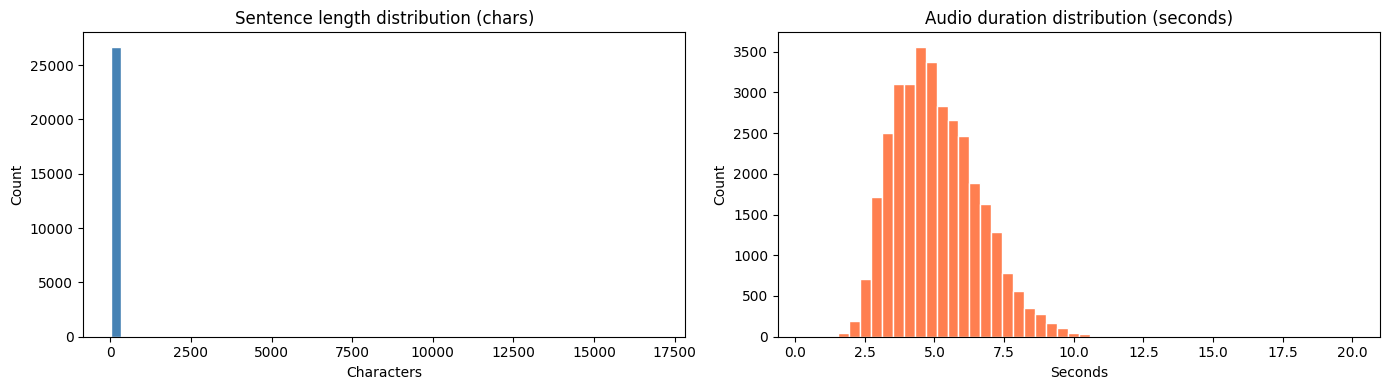


Sentence length stats (train):
count    26688.000000
mean        65.640363
std        145.488607
min          6.000000
25%         46.000000
50%         62.000000
75%         79.000000
max      16984.000000


In [7]:
# ── Distribution: sentence character length ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sent_lengths = df_train["sentence"].str.len()
axes[0].hist(sent_lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Sentence length distribution (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

# Audio duration distribution from clip_durations.tsv if available
dur_tsv = DATASET_ROOT / "clip_durations.tsv"
if dur_tsv.exists():
    df_dur = pd.read_csv(dur_tsv, sep="\t")
    df_dur = df_dur.rename(columns={c: "duration_ms" for c in df_dur.columns if "duration" in c.lower()})
    df_dur["duration_ms"] = pd.to_numeric(df_dur["duration_ms"], errors="coerce")
    # Filter to validated clips
    validated_clips = set(df["path"].values)
    df_dur_valid = df_dur[df_dur["clip"].isin(validated_clips)]
    durations_sec = df_dur_valid["duration_ms"] / 1000
    axes[1].hist(durations_sec, bins=50, color="coral", edgecolor="white")
    axes[1].set_title("Audio duration distribution (seconds)")
    axes[1].set_xlabel("Seconds")
    axes[1].set_ylabel("Count")
    total_hours = durations_sec.sum() / 3600
    train_hours = total_hours * TRAIN_RATIO
    print(f"Total validated audio: {total_hours:.1f} hours")
    print(f"Training set estimate: {train_hours:.1f} hours")
else:
    axes[1].text(0.5, 0.5, "clip_durations.tsv not found", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print(f"\nSentence length stats (train):")
print(sent_lengths.describe().to_string())

## 7. Load Processor (Feature Extractor + Tokenizer)

In [8]:
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained(
    MODEL_ID,
    language=LANGUAGE,
    task=TASK,
)

feature_extractor = processor.feature_extractor
tokenizer         = processor.tokenizer

print(f"Processor loaded from: {MODEL_ID}")
print(f"Language: {LANGUAGE}  |  Task: {TASK}")
print(f"Sampling rate: {feature_extractor.sampling_rate} Hz")

Processor loaded from: openai/whisper-medium
Language: mongolian  |  Task: transcribe
Sampling rate: 16000 Hz


## 8. Build HuggingFace Datasets & Preprocess

In [9]:
import json
import shutil
import numpy as np
from tqdm.auto import tqdm

TARGET_SR          = feature_extractor.sampling_rate   # 16000
CACHE_DIR          = OUTPUT_DIR / "feature_cache"
MAX_SENTENCE_CHARS = 200   # filters 17 corrupted rows (p99 of normal = 111 chars)

CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Disk space guard ────────────────────────────────────────────────────────
free_gb = shutil.disk_usage(".").free / 1e9
print(f"Free disk space: {free_gb:.1f} GB  (need ~16 GB)")
assert free_gb >= 16, f"Not enough disk space: {free_gb:.1f} GB"

# ── Custom Dataset backed by numpy memmap ───────────────────────────────────
class WhisperMemmapDataset(torch.utils.data.Dataset):
    """Read-only view of precomputed float16 mel spectrograms via memmap.

    __getitem__ reads one (80, 3000) slice from disk (~480 KB).
    Safe with dataloader_num_workers > 0: read-only mmap is
    copy-on-write shareable across forked DataLoader workers on Linux.
    """
    def __init__(self, feat_path, label_path, n_samples):
        self.features = np.memmap(
            str(feat_path), dtype=np.float16, mode="r", shape=(n_samples, 80, 3000)
        )
        with open(label_path) as f:
            self.labels = json.load(f)
        assert len(self.labels) == n_samples

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_features": np.array(self.features[idx]),   # float16 [80, 3000]
            "labels": self.labels[idx],
        }

print("WhisperMemmapDataset defined.")

Building HF datasets...
train: 26,688  |  val: 3,336  |  test: 3,337


In [ ]:
def preprocess_to_memmap(df_split, split_name):
    """Decode audio → log-Mel (float16) → write to memmap + labels JSON.

    Why memmap instead of datasets.map():
      datasets 4.8.4 buffers the full output in memory before writing Arrow
      files — Python reached 50–61 GB RSS and was killed by the OOM killer.
      np.memmap writes each row directly to disk; peak RAM stays ~2–5 MB.

    Skips preprocessing if cache files already exist with the correct size.
    """
    feat_path  = CACHE_DIR / f"{split_name}_features.bin"
    label_path = CACHE_DIR / f"{split_name}_labels.json"

    # Filter corrupted rows
    df_clean = df_split[
        df_split["sentence"].str.strip().str.len().between(1, MAX_SENTENCE_CHARS)
    ].reset_index(drop=True)
    n = len(df_clean)

    # Cache hit: file exists and byte-size matches expected shape
    expected_bytes = n * 80 * 3000 * 2   # float16 = 2 bytes/element
    if feat_path.exists() and label_path.exists() and feat_path.stat().st_size == expected_bytes:
        print(f"{split_name}: cache hit ({n:,} samples) — skipping preprocessing")
        return WhisperMemmapDataset(feat_path, label_path, n)

    print(f"{split_name}: preprocessing {n:,} samples → {expected_bytes/1e9:.2f} GB ...")

    # Pre-allocate binary file on disk (does NOT load into RAM)
    mmap = np.memmap(str(feat_path), dtype=np.float16, mode="w+", shape=(n, 80, 3000))

    all_labels = []
    for i, (_, row) in enumerate(tqdm(df_clean.iterrows(), total=n, desc=split_name)):
        audio, _ = librosa.load(str(CLIPS_DIR / row["path"]), sr=TARGET_SR, mono=True)
        mel = feature_extractor(audio, sampling_rate=TARGET_SR).input_features[0]
        mmap[i] = mel.astype(np.float16)   # written to disk immediately
        all_labels.append(tokenizer(row["sentence"]).input_ids)
        del audio, mel                      # free ~2 MB each iteration

    del mmap   # flush remaining pages and close file handle

    with open(label_path, "w") as f:
        json.dump(all_labels, f)

    print(f"{split_name}: done  {feat_path.stat().st_size/1e9:.2f} GB")
    return WhisperMemmapDataset(feat_path, label_path, n)


print("Preprocessing (first run ~15–30 min for train, instant on re-runs)...")
train_dataset = preprocess_to_memmap(df_train, "train")
val_dataset   = preprocess_to_memmap(df_val,   "val")
test_dataset  = preprocess_to_memmap(df_test,  "test")
print(f"\nDone  train={len(train_dataset):,}  val={len(val_dataset):,}  test={len(test_dataset):,}")


Free disk space: 1262.5 GB (need ~16 GB)


Filter (num_proc=1):   0%|          | 0/26688 [00:00<?, ? examples/s]

Filter (num_proc=1):   0%|          | 0/3336 [00:00<?, ? examples/s]

Filter (num_proc=1):   0%|          | 0/3337 [00:00<?, ? examples/s]

Filtered 17 corrupted samples  (33,361 → 33,344 total)
  train: 26,678  val: 3,333  test: 3,333
Preprocessing train set (~12.8 GB cache, runs once)...


Map (num_proc=1):   0%|          | 0/26678 [00:00<?, ? examples/s]

## 9. Data Collator

In [ ]:
import torch
import numpy as np
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """Pad precomputed float16 features and tokenised labels into a batch."""
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Cast float16 → float32 for padding (feature_extractor.pad expects float32)
        input_features = [
            {"input_features": np.array(f["input_features"], dtype=np.float32)}
            for f in features
        ]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=processor.tokenizer.bos_token_id,
)
print("Data collator ready (float16 cache → float32 padding).")

## 10. Load Model

In [ ]:
from transformers import WhisperForConditionalGeneration

model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)

# Language / task tokens baked into the decoder forced ids during fine-tuning
# Set forced_decoder_ids to None — the generation config handles this
model.config.forced_decoder_ids = None
model.config.suppress_tokens = []

# Enable gradient checkpointing to reduce VRAM usage
model.config.use_cache = False          # required when gradient_checkpointing=True
model.gradient_checkpointing_enable()

num_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_ID}")
print(f"Parameters: {num_params/1e6:.0f} M")
print(f"Gradient checkpointing: enabled")

# Set generation language/task for inference
model.generation_config.language = LANGUAGE
model.generation_config.task = TASK
model.generation_config.forced_decoder_ids = None

## 11. WER Metric

In [ ]:
import evaluate
from transformers.models.whisper.english_normalizer import BasicTextNormalizer

wer_metric  = evaluate.load("wer")
normalizer  = BasicTextNormalizer()

def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids

    # Replace -100 padding back to pad_token_id before decoding
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Normalise (lowercase, remove punctuation)
    pred_str_norm  = [normalizer(p) for p in pred_str]
    label_str_norm = [normalizer(l) for l in label_str]

    # Filter empty references
    pred_str_norm, label_str_norm = zip(
        *[(p, l) for p, l in zip(pred_str_norm, label_str_norm) if len(l) > 0]
    ) if any(len(l) > 0 for l in label_str_norm) else ([], [])

    wer = 100 * wer_metric.compute(predictions=list(pred_str_norm), references=list(label_str_norm))
    return {"wer": wer}

print("WER metric loaded.")

## 12. Training Arguments

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),

    # ── Precision & memory ────────────────────────────────────────────────
    bf16=True,
    fp16=False,
    gradient_checkpointing=True,

    # ── Batch sizes ───────────────────────────────────────────────────────
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # ── Optimiser ─────────────────────────────────────────────────────────
    optim="adamw_bnb_8bit",   # 8-bit AdamW via bitsandbytes, halves optimizer VRAM
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    label_smoothing_factor=LABEL_SMOOTHING,

    # ── Steps / epochs ────────────────────────────────────────────────────
    max_steps=MAX_STEPS,

    # ── Evaluation & checkpointing ────────────────────────────────────────
    evaluation_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    # ── Generation during eval ────────────────────────────────────────────
    predict_with_generate=True,
    generation_max_length=225,

    # ── Logging ───────────────────────────────────────────────────────────
    logging_dir=str(LOG_DIR),
    logging_steps=25,
    report_to=["tensorboard"],

    # ── Hub ───────────────────────────────────────────────────────────────
    push_to_hub=True,
    hub_model_id=HUB_REPO,
    hub_strategy="checkpoint",

    # ── Misc ─────────────────────────────────────────────────────────────
    seed=SEED,
    dataloader_num_workers=4,   # safe: workers only read Arrow files, no audio decoding, no CUDA
    dataloader_pin_memory=True,
    remove_unused_columns=False,
)

print("TrainingArguments configured:")
print(f"  bf16                        : {training_args.bf16}")
print(f"  gradient_checkpointing      : {training_args.gradient_checkpointing}")
print(f"  effective batch size (train): {PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"  max_steps                   : {training_args.max_steps}")
print(f"  learning_rate               : {training_args.learning_rate}")
print(f"  report_to                   : {training_args.report_to}")
print(f"  hub_model_id                : {training_args.hub_model_id}")

## 13. Launch TensorBoard

Run this cell before (or during) training to watch metrics live.

In [ ]:
%load_ext tensorboard
log_dir_str = str(LOG_DIR)
%tensorboard --logdir $log_dir_str

## 14. Create Trainer

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

# Save processor alongside model checkpoints
processor.save_pretrained(str(OUTPUT_DIR))
print("Trainer created. Processor saved to output directory.")

## 15. Train

Expected time: ~3–5 hours for 4000 steps on RTX 5080.  
Monitor WER on the TensorBoard tab above.

In [ ]:
print("Starting training...")
print(f"  Steps: {MAX_STEPS}  |  Eval every: {EVAL_STEPS} steps")
print(f"  Output: {OUTPUT_DIR}")

train_result = trainer.train()

# Save training metrics
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()

print("\nTraining complete!")
print(f"  Loss            : {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"  Samples/second  : {train_result.metrics.get('train_samples_per_second', 'N/A'):.2f}")
print(f"  Total train time: {train_result.metrics.get('train_runtime', 0)/3600:.2f} hours")

## 16. Evaluate on Test Set

In [ ]:
print("Evaluating on held-out test set...")

test_results = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test",
)

trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)

test_wer = test_results.get("test_wer", None)
print(f"\n{'='*50}")
print(f"  Test WER : {test_wer:.2f}%" if test_wer is not None else "  WER not found in results")
print(f"  Target   : < 48.00%")
if test_wer is not None:
    status = "PASSED" if test_wer < 48.0 else "NOT YET — consider more steps or lower LR"
    print(f"  Status   : {status}")
print(f"{'='*50}")

## 17. Sample Predictions vs Ground Truth

In [ ]:
import torch

model.eval()
model.to(device)

num_samples = 5
print(f"Generating predictions for {num_samples} test samples:\n")

for i in range(num_samples):
    sample = test_dataset[i]
    # float32 on GPU: conv weights/biases stay fp32; casting only inputs to bf16 breaks generate().
    mel = np.array(sample["input_features"], dtype=np.float32)
    input_features = torch.tensor(mel).unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            language=LANGUAGE,
            task=TASK,
        )

    label_ids = sample["labels"]
    label_ids_clean = [l if l != -100 else processor.tokenizer.pad_token_id for l in label_ids]
    label_text = processor.tokenizer.decode(label_ids_clean, skip_special_tokens=True)
    pred_text  = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)

    print(f"[{i+1}] Reference : {label_text}")
    print(f"     Prediction: {pred_text}")
    print()

## 18. Push Best Checkpoint to Hugging Face Hub

In [ ]:
print(f"Pushing best model to Hub: {HUB_REPO}")

kwargs = {
    "dataset_tags": "mozilla-foundation/common_voice_17_0",
    "dataset": "Common Voice Mongolian 25.0",
    "dataset_args": "config: mn, split: validated",
    "language": "mn",
    "model_name": "Whisper Medium - Mongolian",
    "finetuned_from": MODEL_ID,
    "tasks": "automatic-speech-recognition",
}

trainer.push_to_hub(**kwargs)
processor.push_to_hub(HUB_REPO)

print(f"Model available at: https://huggingface.co/{HUB_REPO}")

## 19. Quick Inference Helper

Load the fine-tuned model later without re-running training.

In [ ]:
from transformers import pipeline

# Load from local output directory (or from Hub: HUB_REPO)
asr_pipe = pipeline(
    "automatic-speech-recognition",
    model=str(OUTPUT_DIR),
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    device=0,
    torch_dtype=torch.bfloat16,
    generate_kwargs={"language": LANGUAGE, "task": TASK},
)

# Test on a sample from the test set
test_audio_path = str(CLIPS_DIR / df_test.iloc[0]["path"])
result = asr_pipe(test_audio_path)
print(f"Transcription: {result['text']}")
print(f"Reference    : {df_test.iloc[0]['sentence']}")